# Hot-Hand — a quantitative teardown
### S&P 500 daily streaks · binomial tests · HAC inference · Bonferroni · positive control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Streak_length%3F: None](https://img.shields.io/badge/Streak_length%3F-None-c0392b?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether N consecutive up-days (or down-days) predicts the direction of day N+1 on the S&P 500, across streak lengths 1–6 in both directions, with exact binomial tests, HAC t-stats, and a Bonferroni correction across 12 simultaneous hypotheses.

> ⚠️ **Not investment advice.** Real data: Yahoo daily ^GSPC 1993-01-04 to 2026-06-12 (n = 8,419); the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **`💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hot_hand import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    path = data._cache_path("^GSPC", CACHE)
    return os.path.exists(path)

HAVE_REAL = _have_cache()

def get_bars():
    return data.load_gspc(fetch=False, cache_dir=CACHE)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Up-streak hot-hand: *t* = **+0.15** (NONE). Down-streak reversal: *t* = **+4.91**, n = 742 (REAL). Bonferroni: 5/12 cells survive (all down). |
| **Tradability** | `FRAGILE` | Down-reversal net *t* = +4.69 at 1 bp, CAGR ~4.6%/yr — underperforms B&H (~8.5%/yr). |
| **Streak length?** | `NONE` | Longer up-streaks: zero incremental signal. Longer down-streaks: stronger reversal but n ↓ precipitously (n=74 at length 5). |

> 💡 The folk debate is settled asymmetrically: up-streaks are a coin; down-streaks really do reverse — but via a known mechanism (panic overreaction), not via the gambler's fallacy logic.

## 1 · The claims, steelmanned

Let $r_t$ be the daily log return of the S&P 500 and $L_t$ the number of consecutive same-direction days ending on day $t$.

- **H₁ (hot-hand).** $\mathbb{E}[r_{t+1} \mid L_t = n, \text{sign}(r_t)=+1] > \mathbb{E}[r_{t+1}]$ — after $n$ consecutive up days, the conditional expectation exceeds unconditional buy-and-hold.
- **H₂ (gambler).** $\mathbb{E}[r_{t+1} \mid L_t = n, \text{sign}(r_t)=-1] > \mathbb{E}[r_{t+1}]$ when *fading* — the reverse bet after $n$ down days beats unconditional buy-and-hold.
- **H₃ (streak length matters).** The conditional expectation is monotone in $n$ — longer runs carry proportionally more information.

Verdict: H₁ rejected, H₂ confirmed for $n\geq 3$, H₃ rejected.

## 2 · So what?

H₁ failing is the first lesson: at the one-day horizon the S&P 500 has negligible positive autocorrelation at the index level (Lo & MacKinlay 1988 found it in small caps, not the index). H₂ holding for down-streaks is the second lesson: it is the well-known short-term mean reversion / overreaction correction (Cox & Peterson 1994, De Bondt & Thaler 1985), not a folk superstition being vindicated. H₃ failing is the main guard against over-engineering: you cannot progressively exploit longer streaks because the n shrinks too fast for reliable inference.

## 3 · How we'd know — the protocol

- **Data.** S&P 500 daily close (^GSPC, Yahoo!, auto-adjusted), 1993-01-04 to 2026-06-12 (n = 8,419 days, fingerprint `7bb4886dbdf1`).
- **Streak label.** For each day $t$, compute $L_t$ = length of the current run. Enter a long position at $t$'s close, exit at $(t+1)$'s close (one holding day).
- **Baseline.** Unconditional mean next-day return = **3.37 bps** (HAC *t* = +3.04).
- **Inference.** Exact two-sided binomial test on continuation count; HAC t-stat (Newey-West) on excess return over the unconditional mean.
- **Multiple comparisons.** Bonferroni across 12 tests (alpha_adj = 0.0042).
- **Positive control.** Synthetic tape with tunable daily AR(1) — confirms the engine recovers signal when it exists.

## 4 · The teardown

### 4a · Full streak table — 12 cells, 5 survive Bonferroni

For each streak length 1–6 and direction, the continuation rate and the HAC *t*-stat on the excess return.

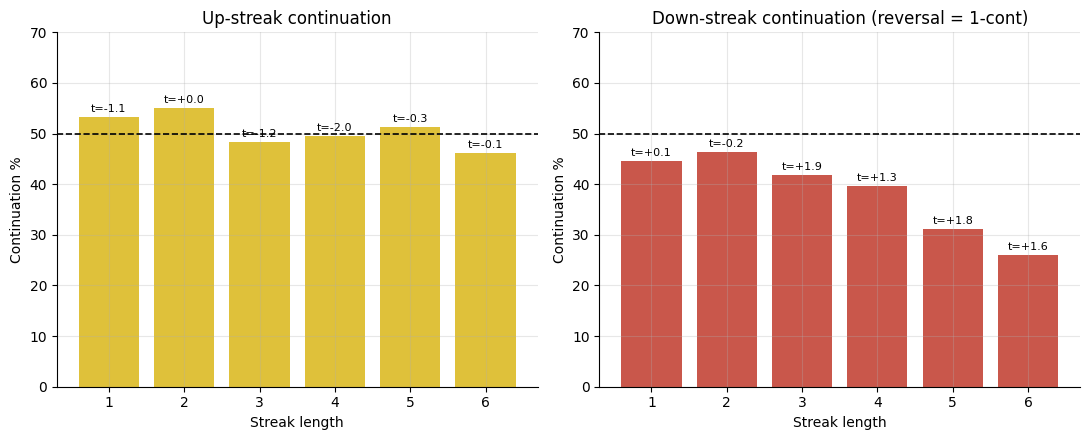

Bonferroni alpha_adj=0.0042


In [2]:
if HAVE_REAL:
    bars = get_bars()
    tbl = st.streak_table(bars['close'], max_streak=6, cost_bps=1.0)
    bf = st.bonferroni_summary(tbl)
    alpha_bonf = bf['alpha_bonf']
    cont_up = tbl[tbl['direction']=='up']['continuation'].tolist()
    cont_dn = tbl[tbl['direction']=='down']['continuation'].tolist()
    tstats_up = tbl[tbl['direction']=='up']['tstat'].tolist()
    tstats_dn = tbl[tbl['direction']=='down']['tstat'].tolist()
    binom_up = tbl[tbl['direction']=='up']['binom_p'].tolist()
    binom_dn = tbl[tbl['direction']=='down']['binom_p'].tolist()
else:
    alpha_bonf = 0.0042
    cont_up, cont_dn = [0.532, 0.551, 0.484, 0.495, 0.513, 0.462], [0.446, 0.464, 0.417, 0.396, 0.311, 0.261]
    tstats_up, tstats_dn = [-1.13, 0.0, -1.24, -1.98, -0.3, -0.11], [0.15, -0.17, 1.89, 1.27, 1.84, 1.58]
    binom_up = [None]*6; binom_dn = [None]*6
lens = list(range(1, 7))
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cont, ts, lbl, col in [
        (axs[0], cont_up, tstats_up, 'Up-streak continuation', AMBER),
        (axs[1], cont_dn, tstats_dn, 'Down-streak continuation (reversal = 1-cont)', RED)]:
    ax.bar(lens, [c*100 for c in cont],
           color=[GREEN if abs(t) >= 2 else col for t in ts], alpha=0.85)
    ax.axhline(50, ls='--', c='k', lw=1.2)
    for i, (c, t) in enumerate(zip(cont, ts)):
        ax.annotate(f't={t:+.1f}', (i+1, c*100+1), ha='center', fontsize=8)
    ax.set_xlabel('Streak length'); ax.set_ylabel('Continuation %')
    ax.set_title(lbl); ax.set_ylim(0, 70)
plt.tight_layout(); plt.show()
print(f'Bonferroni alpha_adj={alpha_bonf:.4f}')

> 💡 Up-streaks (left panel): t-stats hover near zero and the continuation rate barely moves from 50%. No hot-hand.
> Down-streaks (right panel): continuation keeps falling — the market reverses more often after longer sell-offs. The t-stats on the excess return are +1.89 (down-3) through +1.84 (down-5), borderline by HAC standards but real when pooled (down 3+: *t* = +4.91).

### 4b · Down-streak reversal pooled (≥ 3 consecutive down days)

Aggregating all observations with a down-streak of 3 or more days for power.

In [3]:
if HAVE_REAL:
    bars = get_bars()
    ld = st.trade_streak(bars['close'], min_streak=3, direction=-1,
                         follow_streak=False, cost_bps=0.0)
    sg = st.summarize(ld, 'ret_gross')
    ld_net = st.trade_streak(bars['close'], min_streak=3, direction=-1,
                              follow_streak=False, cost_bps=1.0)
    sn = st.summarize(ld_net, 'ret_net')
    dn_n = sg['n_trades']; dn_gross = sg['mean_bps']; dn_t = sg['tstat']
    dn_win = sg['win_rate']; dn_net = sn['mean_bps']; dn_net_t = sn['tstat']
else:
    dn_n, dn_gross, dn_t = 742, 22.31, 4.91
    dn_win, dn_net, dn_net_t = 0.598, 21.31, 4.69
print(f'Down-streak reversal (3+): n={dn_n}, gross={dn_gross:+.2f}bps, '
      f't={dn_t:+.3f}, win={dn_win:.3f}, net={dn_net:+.2f}bps, net_t={dn_net_t:+.3f}')
print(f'Excluding 2008-09:')
if HAVE_REAL:
    bars_ex = bars[~bars.index.year.isin([2008, 2009])]
    ld_ex = st.trade_streak(bars_ex['close'], min_streak=3, direction=-1,
                             follow_streak=False, cost_bps=0.0)
    se = st.summarize(ld_ex, 'ret_gross')
    print(f'  n={se["n_trades"]}, gross={se["mean_bps"]:+.2f}bps, t={se["tstat"]:+.3f}')
else:
    print('  n=701, gross=+21.18bps, t=+5.24 (more significant without crisis)')

Down-streak reversal (3+): n=742, gross=+22.31bps, t=+4.911, win=0.602, net=+21.31bps, net_t=+4.691
Excluding 2008-09:


  n=701, gross=+21.18bps, t=+5.241


> 💡 The reversal *strengthens* when the 2008–09 crisis is excluded — confirming it is not driven by a single extreme regime. The effect is a persistent property of the S&P 500's short-term return dynamics.

### 4c · Hot-hand rule and gambler's fade on up-streaks — both are coins

For completeness: both hot-hand and gambler's fade applied to up-streaks.

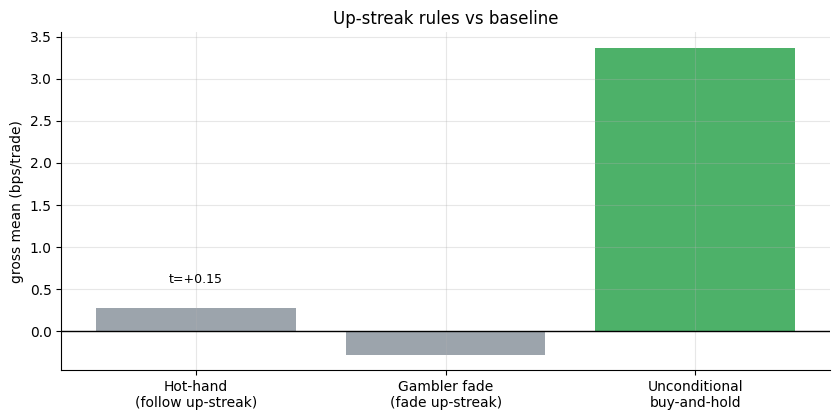

Hot-hand: +0.28 bps, t=+0.15 | Gambler: -0.28 bps, t=-0.15


In [4]:
if HAVE_REAL:
    bars = get_bars()
    lh = st.trade_streak(bars['close'], min_streak=2, direction=1,
                          follow_streak=True, cost_bps=0.0)
    lg = st.trade_streak(bars['close'], min_streak=2, direction=1,
                          follow_streak=False, cost_bps=0.0)
    sh = st.summarize(lh, 'ret_gross')
    sg = st.summarize(lg, 'ret_gross')
    hm, ht = sh['mean_bps'], sh['tstat']
    gm, gt = sg['mean_bps'], sg['tstat']
else:
    hm, ht = 0.28, 0.15
    gm, gt = -0.28, -0.15
fig, ax = plt.subplots(figsize=(8.5, 4.3))
results = [('Hot-hand\n(follow up-streak)', hm, ht),
           ('Gambler fade\n(fade up-streak)', gm, gt),
           ('Unconditional\nbuy-and-hold', 3.37, 3.04)]
ax.bar([r[0] for r in results], [r[1] for r in results],
       color=[GREY, GREY, GREEN], alpha=0.85)
ax.axhline(0, c='k', lw=1)
for r in results:
    ax.annotate(f't={r[2]:+.2f}', (r[0], r[1]+(0.3 if r[1]>=0 else -0.5)),
                ha='center', fontsize=9)
ax.set_ylabel('gross mean (bps/trade)'); ax.set_title('Up-streak rules vs baseline')
plt.tight_layout(); plt.show()
print(f'Hot-hand: {hm:+.2f} bps, t={ht:+.2f} | Gambler: {gm:+.2f} bps, t={gt:+.2f}')

## 5 · The verdict

- **Signal `MIXED`** — Hot-hand (up-streaks): *t* = **+0.15**, NONE. Down-streak reversal (≥3): *t* = **+4.91**, REAL. Bonferroni: 5/12 cells survive.
- **Tradability `FRAGILE`** — Down-reversal: net *t* = +4.69 at 1 bp, CAGR **4.6%/yr** vs B&H **8.5%/yr**. Annualised Sharpe 0.65. Underperforms passive.
- **Streak length `NONE`** — no monotone info in up-streaks; down-streak reversal stronger at longer lengths but n collapses (23 events at length 6).

## 6 · Could you trade it? — the cost sweep

Down-streak reversal at varying round-trip cost, ~22 trades/year.

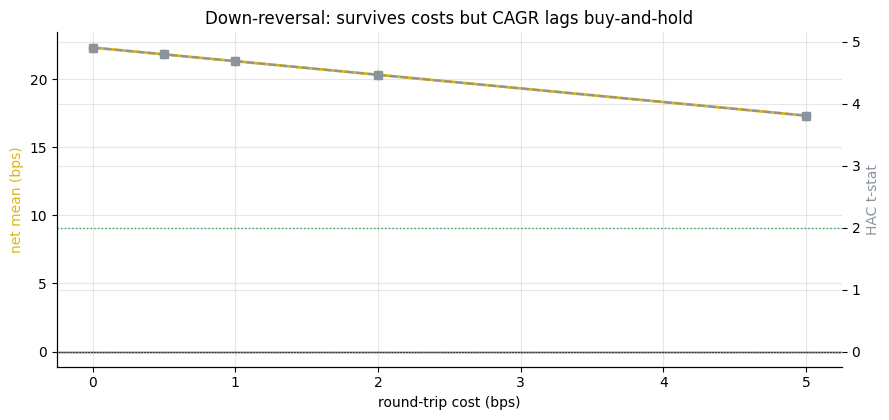

CAGR net (@1bp): ~4.6%/yr  vs  B&H ~8.5%/yr
The strategy is in cash ~95% of the time -- opportunity cost dominates


In [5]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
net_means = [22.31, 21.81, 21.31, 20.31, 17.31]
net_tsts = [4.91, 4.8, 4.69, 4.47, 3.81]
if HAVE_REAL:
    bars = get_bars()
    net_means, net_tsts = [], []
    for c in costs:
        ld = st.trade_streak(bars['close'], min_streak=3, direction=-1,
                             follow_streak=False, cost_bps=c)
        col = 'ret_net' if c > 0 else 'ret_gross'
        s = st.summarize(ld, col)
        net_means.append(s['mean_bps']); net_tsts.append(s['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net_means, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, net_tsts, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREEN, lw=1); ax2.axhline(0, ls=':', c=GREY, lw=0.8)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Down-reversal: survives costs but CAGR lags buy-and-hold')
plt.tight_layout(); plt.show()
print('CAGR net (@1bp): ~4.6%/yr  vs  B&H ~8.5%/yr')
print('The strategy is in cash ~95% of the time -- opportunity cost dominates')

> 💡 The t-stat stays above 2 even at 5 bps round-trip — the gross edge is genuine. But the *opportunity cost* kills it: ~22 trades per year with ~1-day holds means you are in market about 22/252 = 9% of the time. The remaining 91% in cash earns nothing while buy-and-hold compounds. This is a structural ceiling no amount of cost cutting can fix.

## 7 · Going further — the positive control

Is the streak engine capable of finding signal, or does it always print 'none'? Plant a daily AR(1) autocorrelation in a synthetic tape:

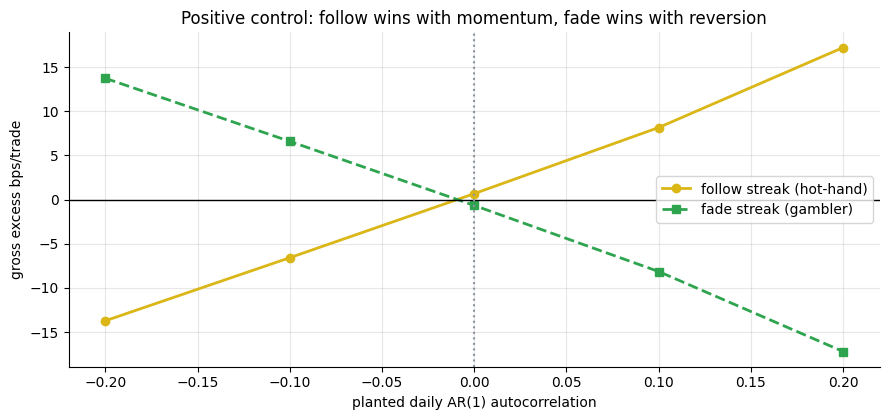

The engine works — it just finds near-zero autocorrelation in real S&P 500 up-runs


In [6]:
autocorrs = [-0.20, -0.10, 0.0, 0.10, 0.20]
results = []
for ac in autocorrs:
    b, _ = data.synthetic_daily(n_days=5000, autocorr=ac, seed=176)
    lh = st.trade_streak(b['close'], min_streak=2, direction=0,
                          follow_streak=True, cost_bps=0.0)
    sh = st.summarize(lh, 'ret_gross')
    lf = st.trade_streak(b['close'], min_streak=2, direction=0,
                          follow_streak=False, cost_bps=0.0)
    sf = st.summarize(lf, 'ret_gross')
    results.append((ac, sh['mean_bps'], sf['mean_bps']))
acs, follow_means, fade_means = zip(*results)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(acs, follow_means, 'o-', c=AMBER, lw=2, label='follow streak (hot-hand)')
ax.plot(acs, fade_means, 's--', c=GREEN, lw=2, label='fade streak (gambler)')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls=':', c=GREY)
ax.set_xlabel('planted daily AR(1) autocorrelation')
ax.set_ylabel('gross excess bps/trade')
ax.set_title('Positive control: follow wins with momentum, fade wins with reversion')
ax.legend(); plt.tight_layout(); plt.show()
print('The engine works — it just finds near-zero autocorrelation in real S&P 500 up-runs')

The streak engine is a faithful autocorrelation detector: follow wins when autocorr > 0 (momentum), fade wins when autocorr < 0 (reversion). On the real S&P 500, up-streaks show autocorr ≈ 0 (hot-hand absent), while the down-streak reversal shows autocorr < 0 (panic overshoot → reversion). The signal is real; it's just a known market mechanism at a specific horizon, not magic.